In [2]:
import pandas as pd
from sklearn import tree
from plotting import create_plots
from time import time

## 1. Läs in datasetet (tabellen med djur)

In [ ]:
djur = pd.read_csv("djur.csv", sep=",", skipinitialspace=True)
print("Träningsdata har laddatsa. Antal djur i datasetet:", len(djur))
print("Exempel på träningsdata:")
djur.sample(5)

Träningsdata har laddats. Antal djur i datasetet: 16
Exempel på träningsdata:


,djurets_namn,merÄn3Ben,fjäll,flyger,simmar,näbb,grupp
14,abborre,0,1,0,1,0,fisk
6,pingvin,0,0,0,1,1,fågel
0,hund,1,0,0,1,0,däggdjur
3,säl,0,0,0,1,0,däggdjur
7,höna,0,0,0,0,1,fågel


## 2. Dela upp tabellen i egenskaper (X) och målvariabel (y) för både tränings- och testdata

In [4]:
feature_names = [column for column in djur.columns if column not in ["djurets_namn", "grupp"]]
X_train = djur[feature_names]
y_train = djur["grupp"]

print(f"Träningsdata har delats upp i {len(feature_names)} features (X_train) och labels (y_train).")

Träningsdata har delats upp i 5 features (X_train) och labels (y_train).


## 3. Träna trädet för att bli så bra som möjligt utifrån träningsdatan

In [5]:
start_time = time()
clf = tree.DecisionTreeClassifier(max_depth=6)
clf.fit(X_train, y_train)
training_time = time() - start_time
print(f"Trädet har tränats på djur-datasetet. Träning tog: {training_time:.3f} sekunder")

Trädet har tränats på djur-datasetet. Träning tog: 0.096 sekunder


### Visa trädet och feature importance

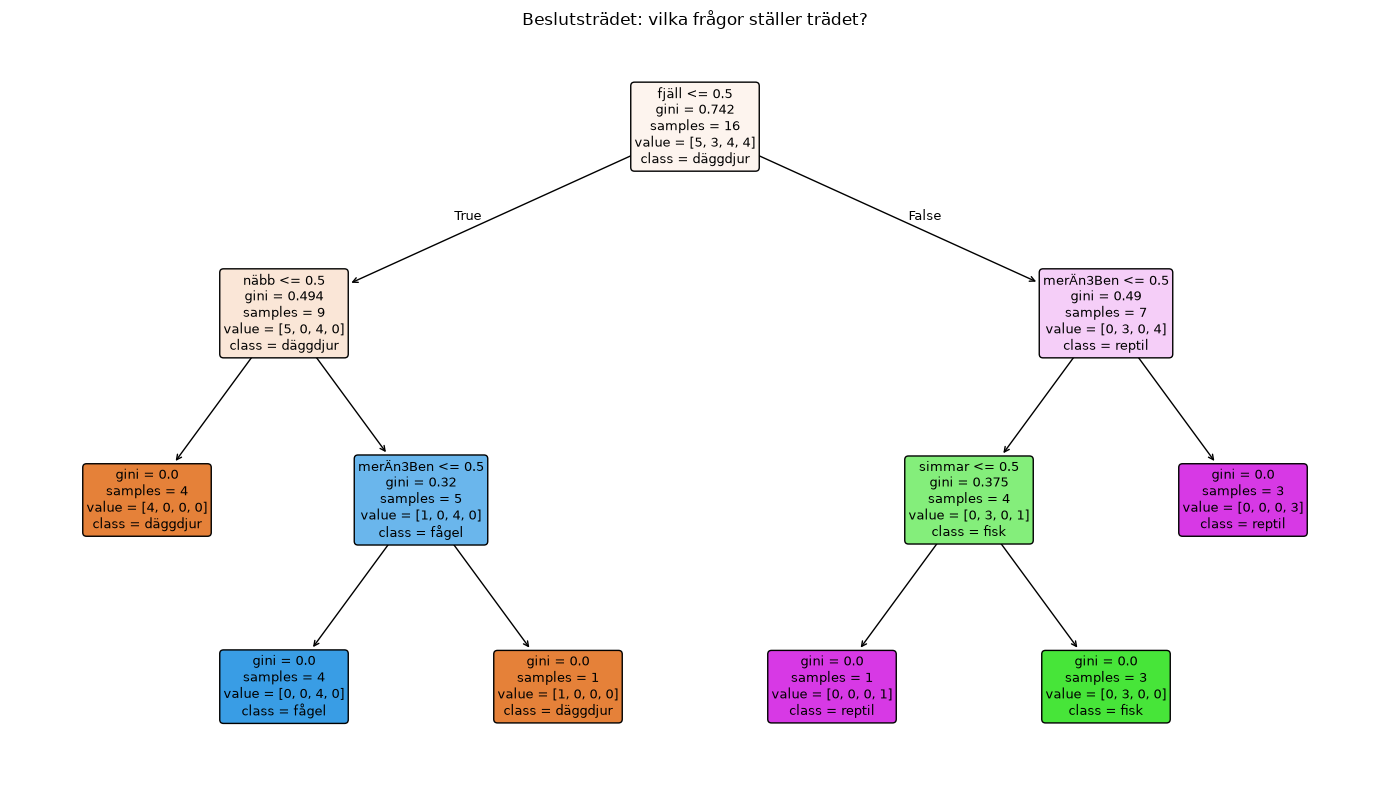

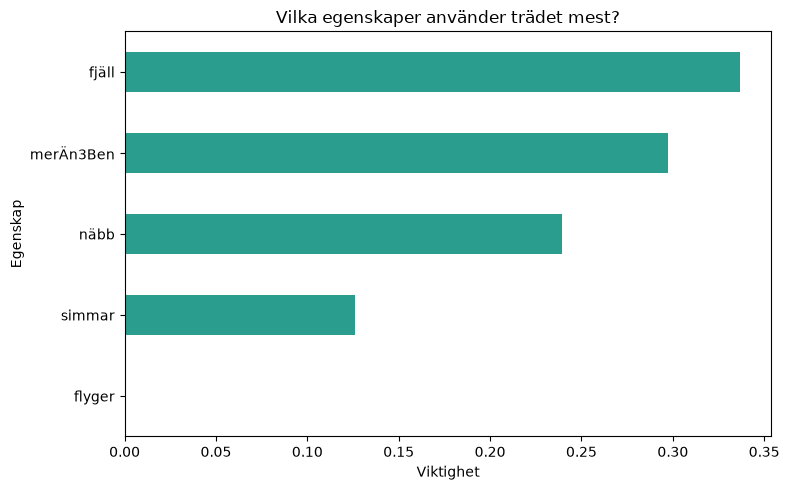

In [6]:
create_plots(clf, feature_names)

## Interaktivt test med nya djur
Nu har vi modellen. Låt oss se om den fungerar genom att testa den på några nya djur utanför träningsdatan!

In [7]:
# Interaktivt test av beslutsträdet med egna värden
print("\nTesta med nytt djur:")

test_animal = [int(input(f"Har djuret {feature}? (ja/nej): ") == "ja") for feature in feature_names]

# Gör en prediktion med det tränade beslutsträdet
test_prediction = clf.predict(pd.DataFrame([test_animal], columns=feature_names))
print(f"\nTrädet gissar att djuret tillhör gruppen: {test_prediction[0]}")


Testa med nytt djur:

Trädet gissar att djuret tillhör gruppen: reptil
